In [9]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt

from core_ntsa.mf_dfa import (
    mf_dfa,
    plot_scaling,
    plot_hq,
    plot_tau,
    plot_summary
)

In [3]:
def generate_monofractal_series(H, N=65536):
    """
    Sinh chuỗi Fractional Gaussian Noise (fGn) với chỉ số Hurst cho trước.
    Sử dụng phương pháp lọc phổ Fourier (Fourier Filtering Method).
    
    Parameters:
        H (float): Chỉ số Hurst (0 < H < 1).
        N (int): Độ dài chuỗi dữ liệu (Mặc định 65536).
        
    Returns:
        numpy.ndarray: Chuỗi thời gian fGn đã được chuẩn hóa (mean=0, std=1).
    """
    # 1. Khởi tạo nhiễu trắng ngẫu nhiên chuẩn
    rng = np.random.default_rng()
    white_noise = rng.standard_normal(N)
    
    # 2. Chuyển sang miền tần số bằng FFT
    X_f = np.fft.rfft(white_noise)
    
    # 3. Tạo trục tần số và tránh lỗi chia cho 0 tại f=0
    freqs = np.fft.rfftfreq(N)
    freqs[0] = 1e-10 
    
    # 4. Áp dụng bộ lọc phân dạng
    # Mật độ phổ công suất của fGn tỷ lệ với f^(1 - 2H)
    # Do đó, biên độ phổ tỷ lệ với f^(0.5 - H)
    filter_amplitude = freqs ** (0.5 - H)
    filter_amplitude[0] = 0  # Đảm bảo kỳ vọng (mean) bằng 0
    
    X_filtered = X_f * filter_amplitude
    
    # 5. Biến đổi ngược (IFFT) về lại miền thời gian
    fgn = np.fft.irfft(X_filtered, n=N)
    
    # 6. Chuẩn hóa chuỗi (Z-score normalization)
    fgn_normalized = (fgn - np.mean(fgn)) / np.std(fgn)
    
    return fgn_normalized

Đang khởi tạo dữ liệu fGn...
Đang xử lý tính toán MF-DFA...
Đang xuất đồ thị thực nghiệm...


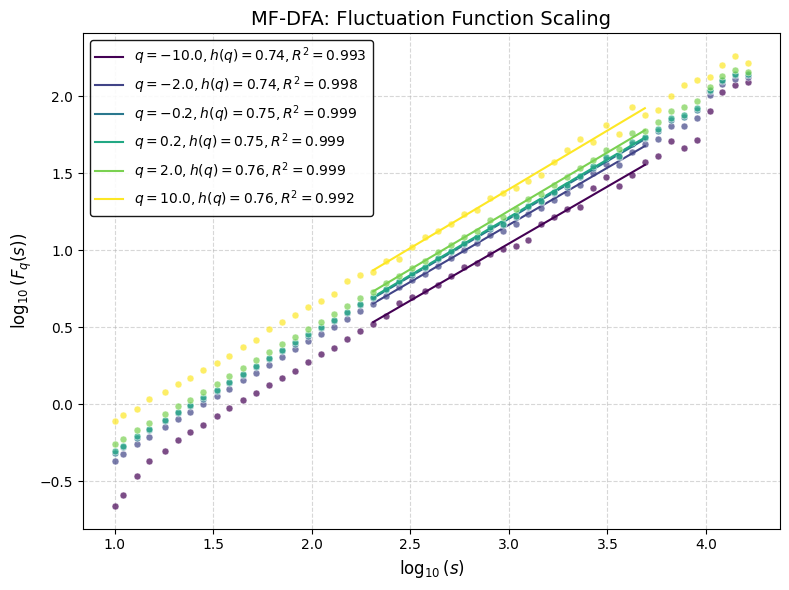

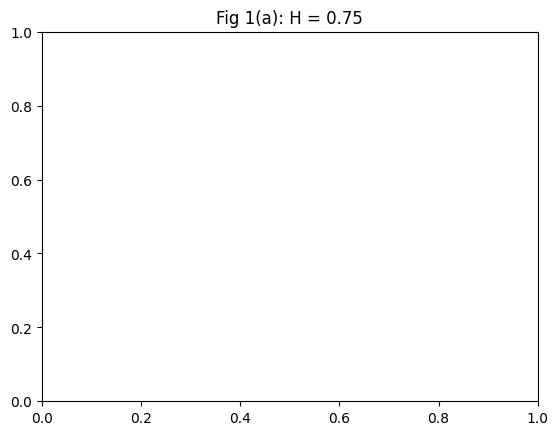

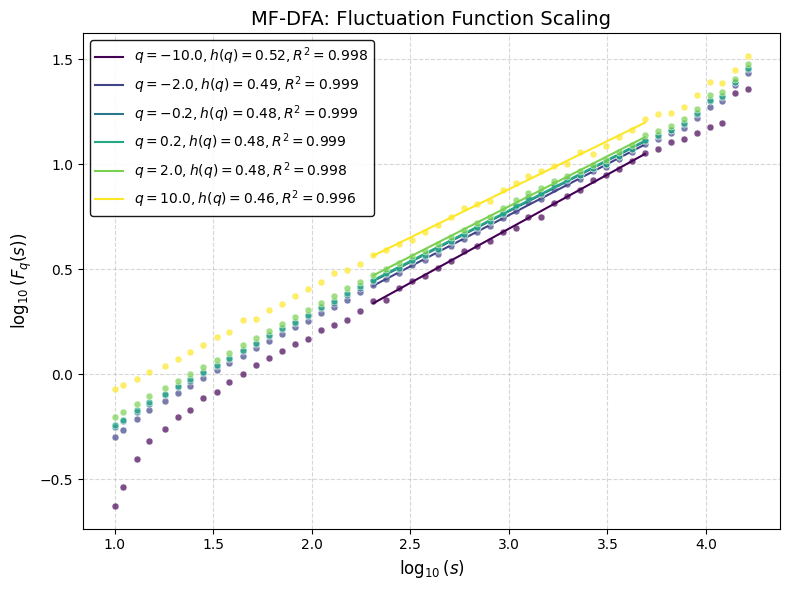

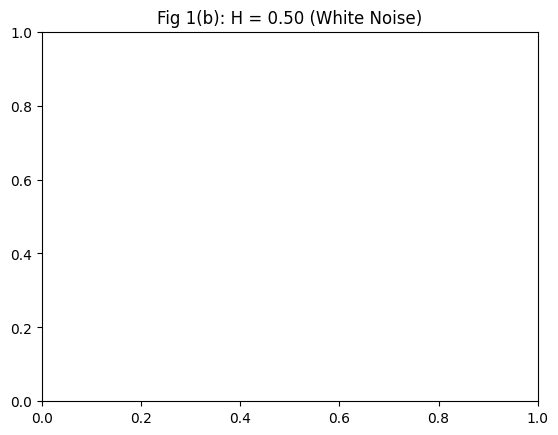

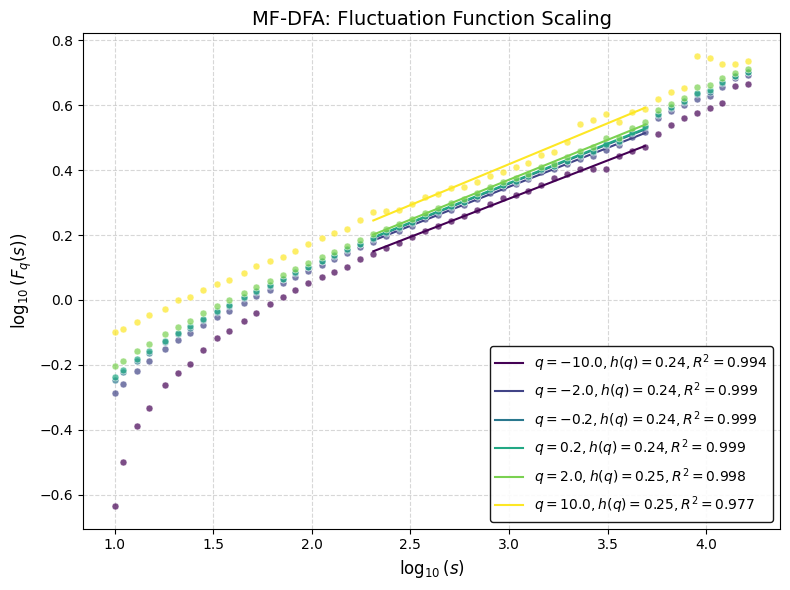

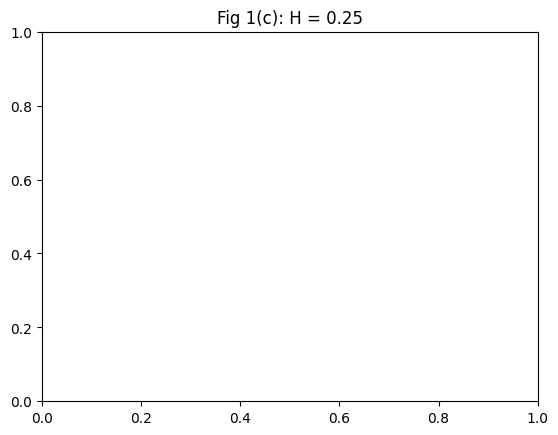

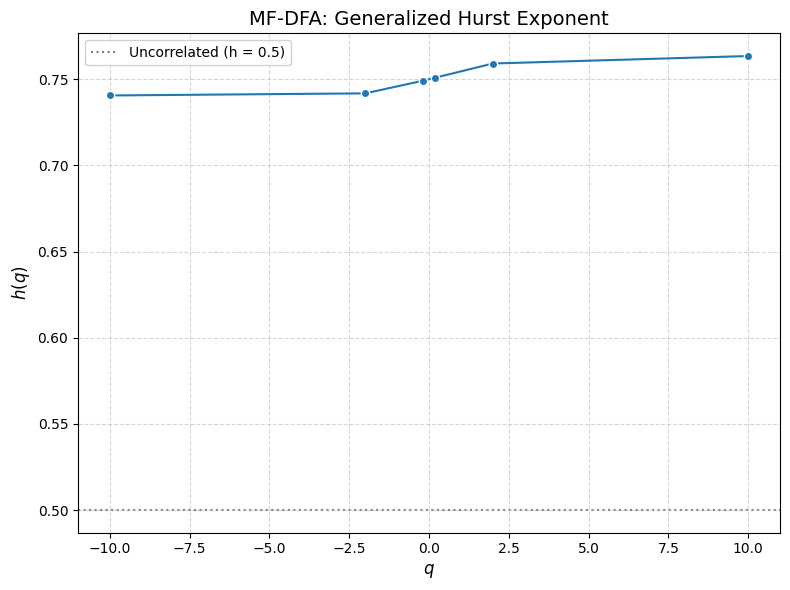

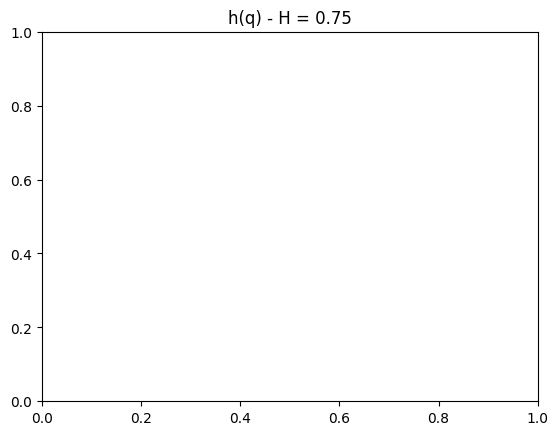

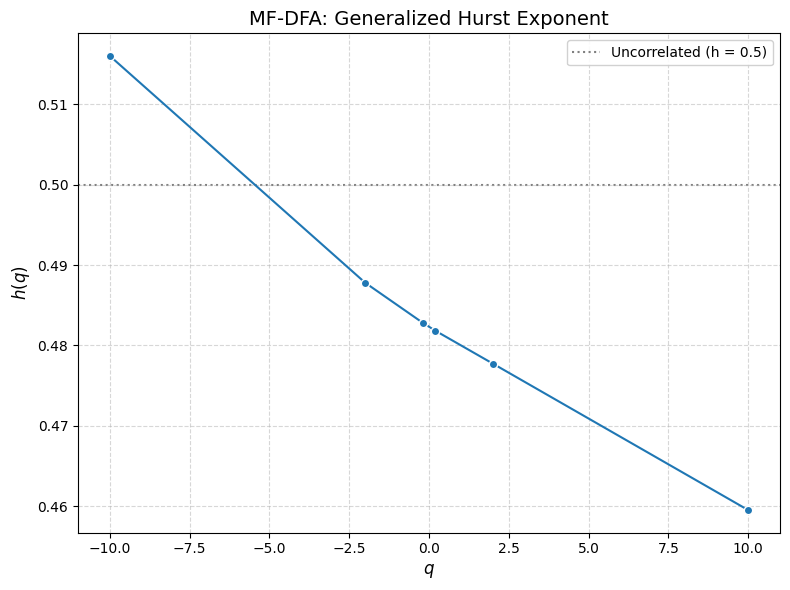

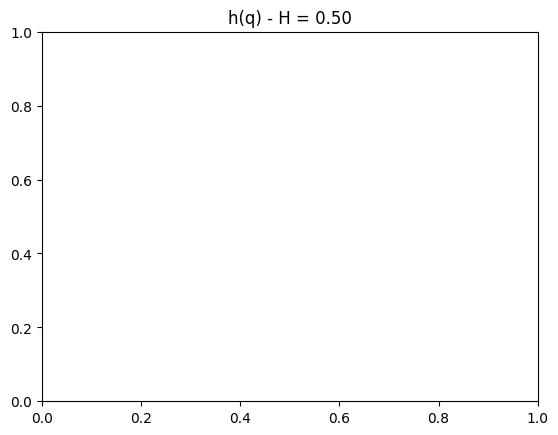

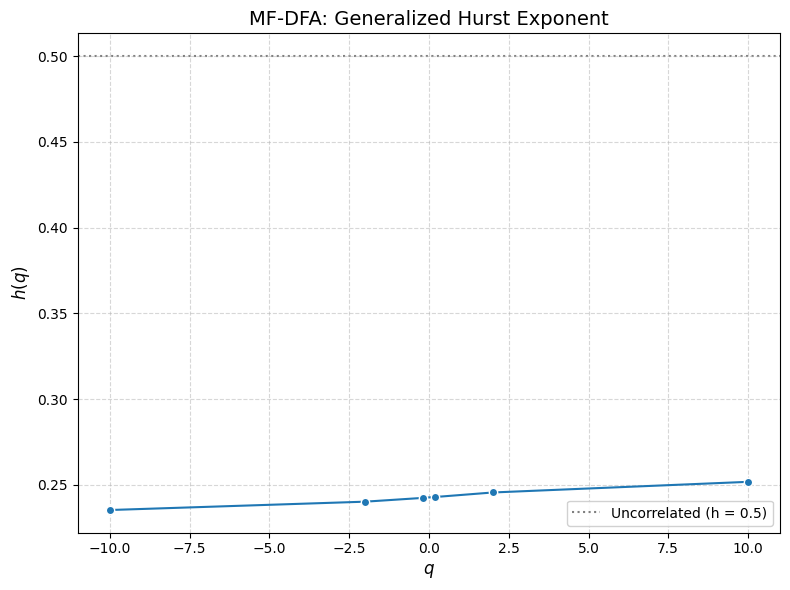

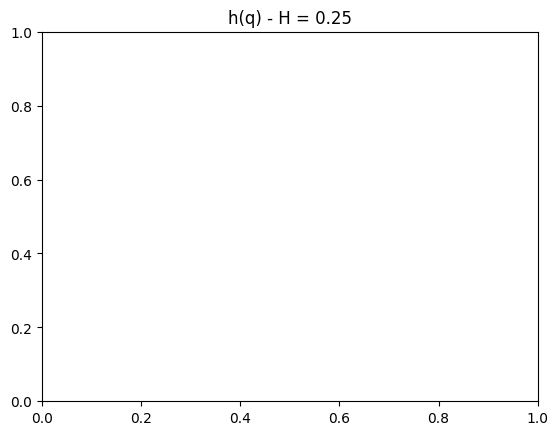

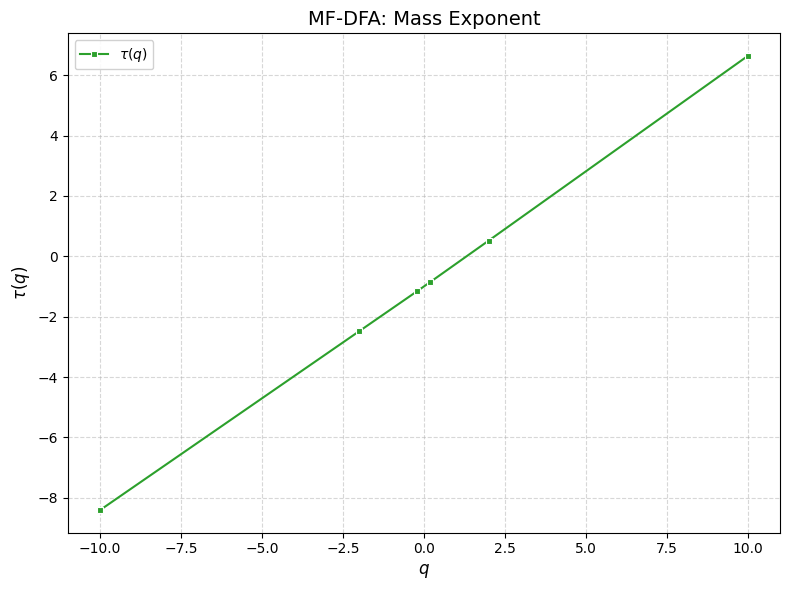

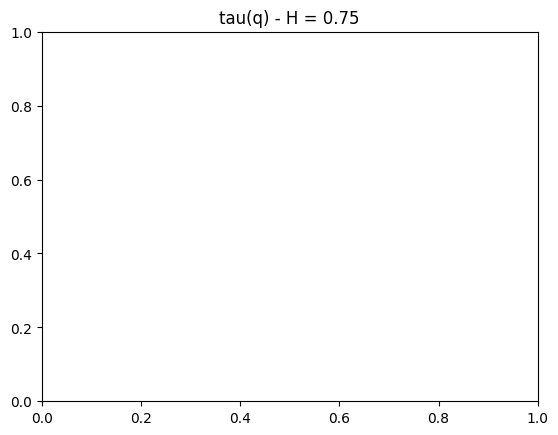

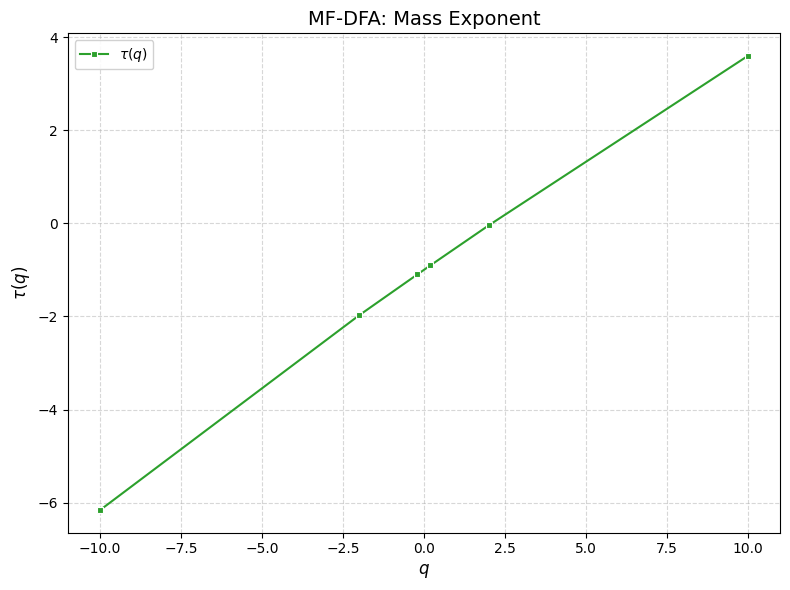

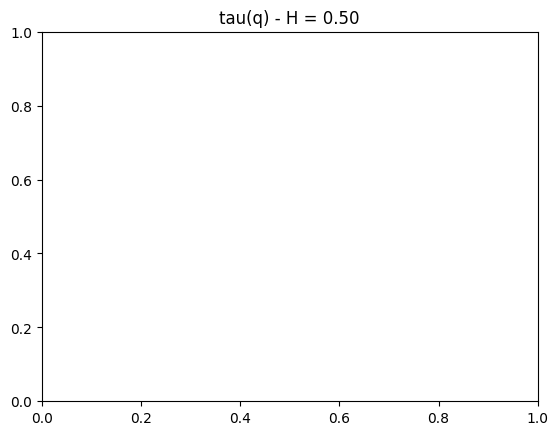

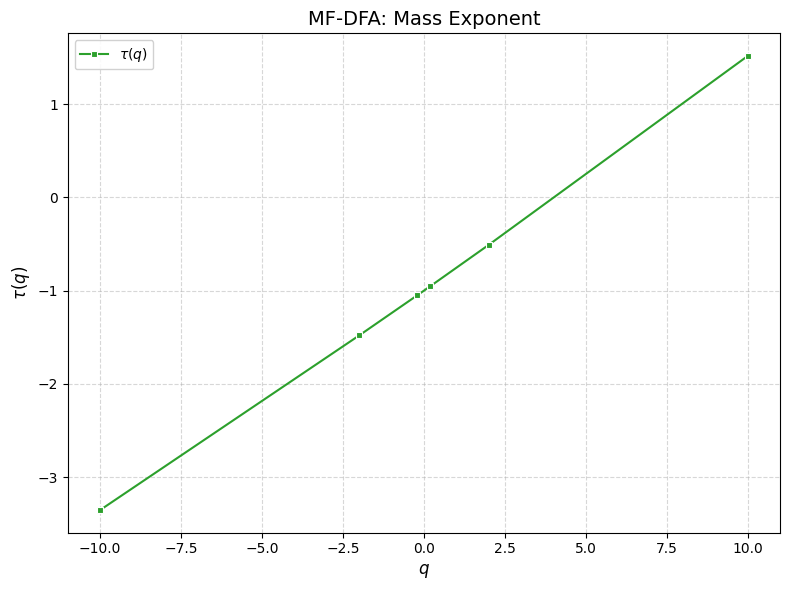

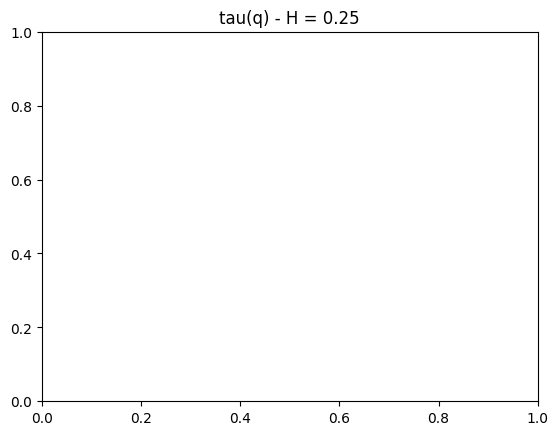

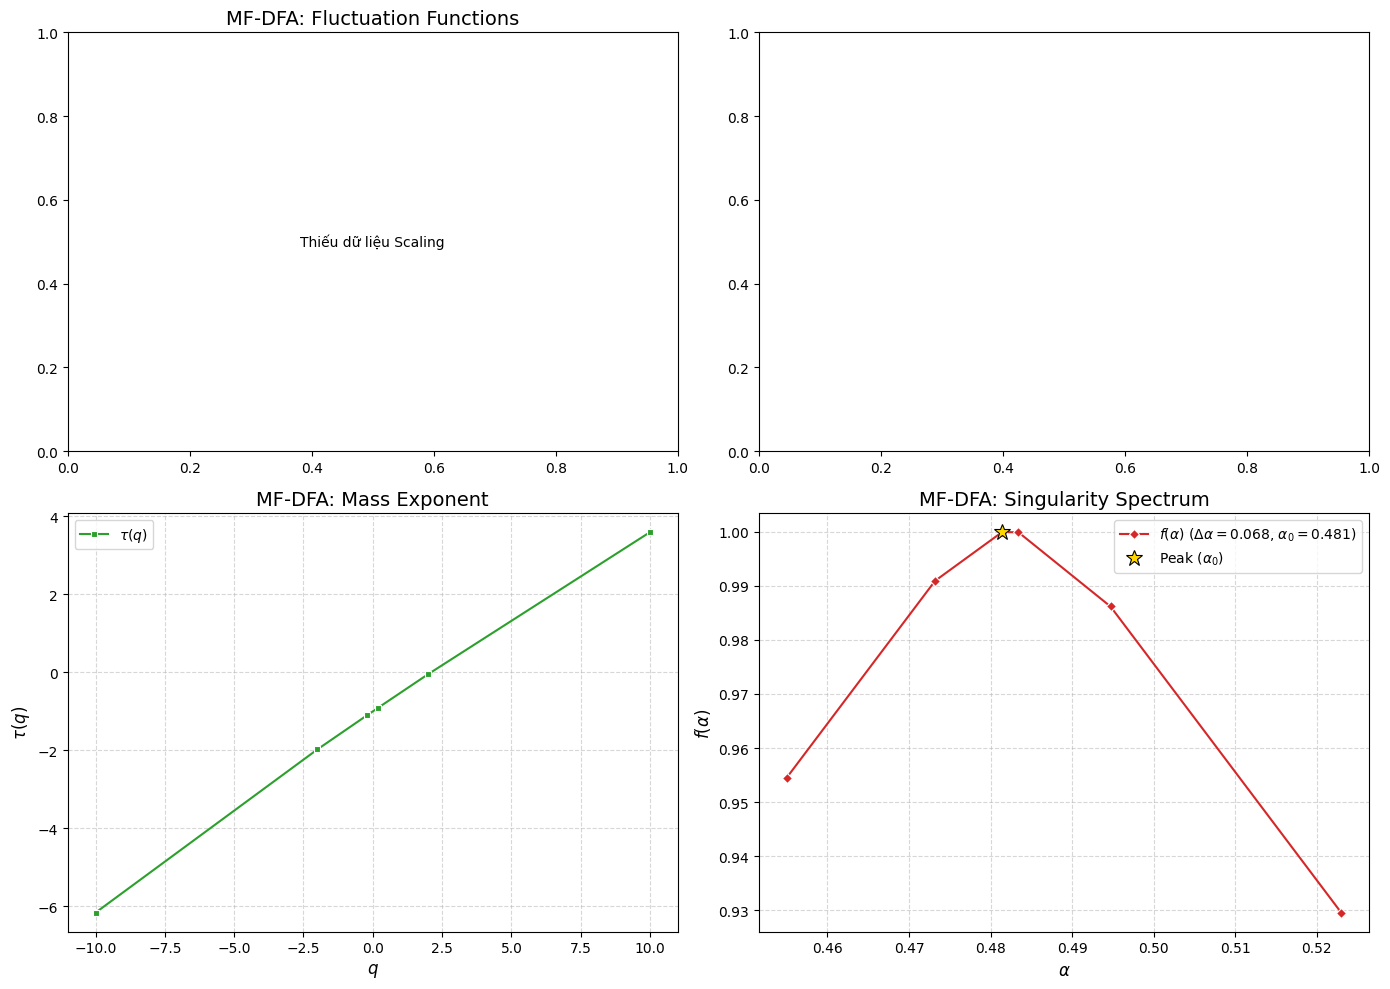

Hoàn tất Thực nghiệm 3.1!


In [10]:
N = 65536
m_order = 2  

# Lăng kính q và mảng s_array
q_values = np.array([-10, -2, -0.2, 0.2, 2, 10])
s_values = np.logspace(np.log10(10), np.log10(N/4), 50).astype(int)

# Tham số fit_range (200, 5000)
min_scale_val = 200
max_ratio_val = int(N / 5000)

print("Đang khởi tạo dữ liệu fGn...")
series_H025 = generate_monofractal_series(H=0.25, N=N)
series_H050 = generate_monofractal_series(H=0.50, N=N)
series_H075 = generate_monofractal_series(H=0.75, N=N)

# ---------------------------------------------------------
# 2. CHẠY PIPELINE MF-DFA (Tuân thủ đúng signature)
# ---------------------------------------------------------
print("Đang xử lý tính toán MF-DFA...")
# Gọi mf_dfa với data, s_array, q_array
results_H025 = mf_dfa(
    data=series_H025, 
    s_array=s_values, 
    q_array=q_values, 
    m=m_order, 
    min_scale=min_scale_val, 
    max_scale_ratio=max_ratio_val
)

results_H050 = mf_dfa(
    data=series_H050, 
    s_array=s_values, 
    q_array=q_values, 
    m=m_order, 
    min_scale=min_scale_val, 
    max_scale_ratio=max_ratio_val
)

results_H075 = mf_dfa(
    data=series_H075, 
    s_array=s_values, 
    q_array=q_values, 
    m=m_order, 
    min_scale=min_scale_val, 
    max_scale_ratio=max_ratio_val
)

# ---------------------------------------------------------
# 3. TRỰC QUAN HÓA KẾT QUẢ (Gọi từng result riêng biệt)
# ---------------------------------------------------------
print("Đang xuất đồ thị thực nghiệm...")

# a) Hàm thăng giáng F_q(s)
# Truyền use_raw=True để quan sát điểm gãy, truyền thêm tham số cho plt qua **kwargs nếu hàm của bạn hỗ trợ
plot_scaling(results_H075, q_values=q_values, use_raw=True)
plt.title("Fig 1(a): H = 0.75") # Ép title sau khi gọi hàm nếu hàm không có plt.show() bên trong

plot_scaling(results_H050, q_values=q_values, use_raw=True)
plt.title("Fig 1(b): H = 0.50 (White Noise)")

plot_scaling(results_H025, q_values=q_values, use_raw=True)
plt.title("Fig 1(c): H = 0.25")

# b) Số mũ Hurst tổng quát h(q)
# Do API chỉ nhận 1 result dict, đồ thị sẽ được tách riêng ra thay vì vẽ chồng
plot_hq(results_H075, show_error=False)
plt.title("h(q) - H = 0.75")

plot_hq(results_H050, show_error=False)
plt.title("h(q) - H = 0.50")

plot_hq(results_H025, show_error=False)
plt.title("h(q) - H = 0.25")

# c) Số mũ khối lượng tau(q)
plot_tau(results_H075)
plt.title("tau(q) - H = 0.75")

plot_tau(results_H050)
plt.title("tau(q) - H = 0.50")

plot_tau(results_H025)
plt.title("tau(q) - H = 0.25")

# d) Bảng Dashboard (Chỉ test với 1 chuỗi)
plot_summary(results_H050, figsize=(14, 10))

plt.show() 
print("Hoàn tất Thực nghiệm 3.1!")